**Proactive Fraud Detection in Financial Transactions**

**Data Dictionary**

**step** - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

**type** - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

**amount** - amount of the transaction in local currency.

**nameOrig** - customer who started the transaction

**oldbalanceOrg** - initial balance before the transaction

**newbalanceOrig** - new balance after the transaction

**nameDest** - customer who is the recipient of the transaction

**oldbalanceDest** - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

**newbalanceDest** - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

**isFraud** - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

**isFlaggedFraud** - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

**Tasks** 

Your task is to execute the process for proactive detection of fraud while answering following
questions.
1. Data cleaning including missing values, outliers and multi-collinearity.
2. Describe your fraud detection model in elaboration.
3. How did you select variables to be included in the model?
4. Demonstrate the performance of the model by using best set of tools.
5. What are the key factors that predict fraudulent customer?
6. Do these factors make sense? If yes, How? If not, How not?
7. What kind of prevention should be adopted while company update its infrastructure?
8. Assuming these actions have been implemented, how would you determine if they work?

In [35]:
#importing required libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
import warnings 
warnings.filterwarnings('ignore') 


In [3]:
#loading the data set 
df = pd.read_csv('/Users/sunilverma/Downloads/Fraud.csv')
df.head(15)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
#checking the demographics of the data set 
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
# checking the null values present in the dataset
round(df.isnull().sum()/len(df)*100,2)

step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
dtype: float64

In [8]:
df['isFraud'].value_counts(normalize = True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [23]:
# separating the numerical data set
num_cols = df.select_dtypes(include = ['int64', 'float64'])
num_cols

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,0
2,1,181.00,181.00,0.00,0.00,0.00,1,0
3,1,181.00,181.00,0.00,21182.00,0.00,1,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,0
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,0
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,0


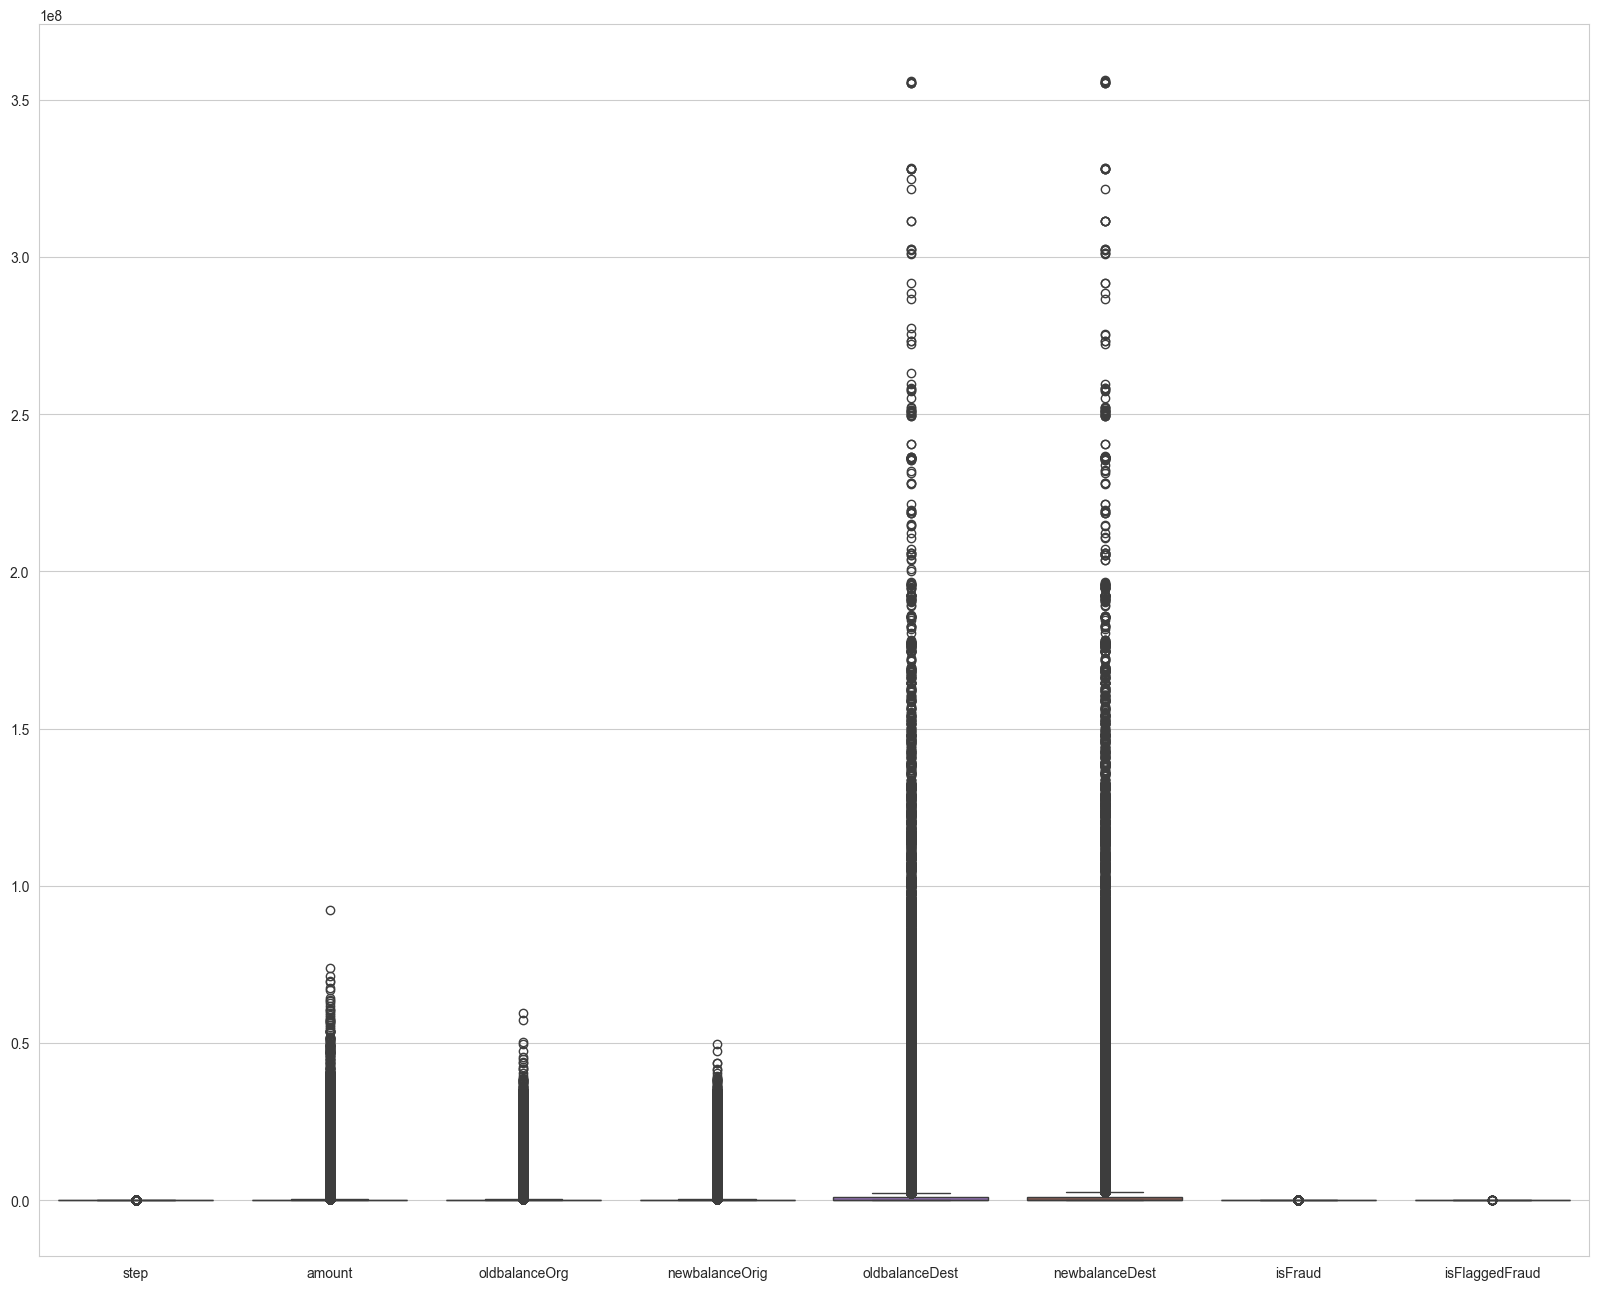

In [10]:
#visulizing the outliers present in the dataset 
plt.figure(figsize=(20,16))
sns.set_style('whitegrid')
sns.boxplot(num_cols)
plt.show()

In [11]:
df_corr = num_cols.corr() 

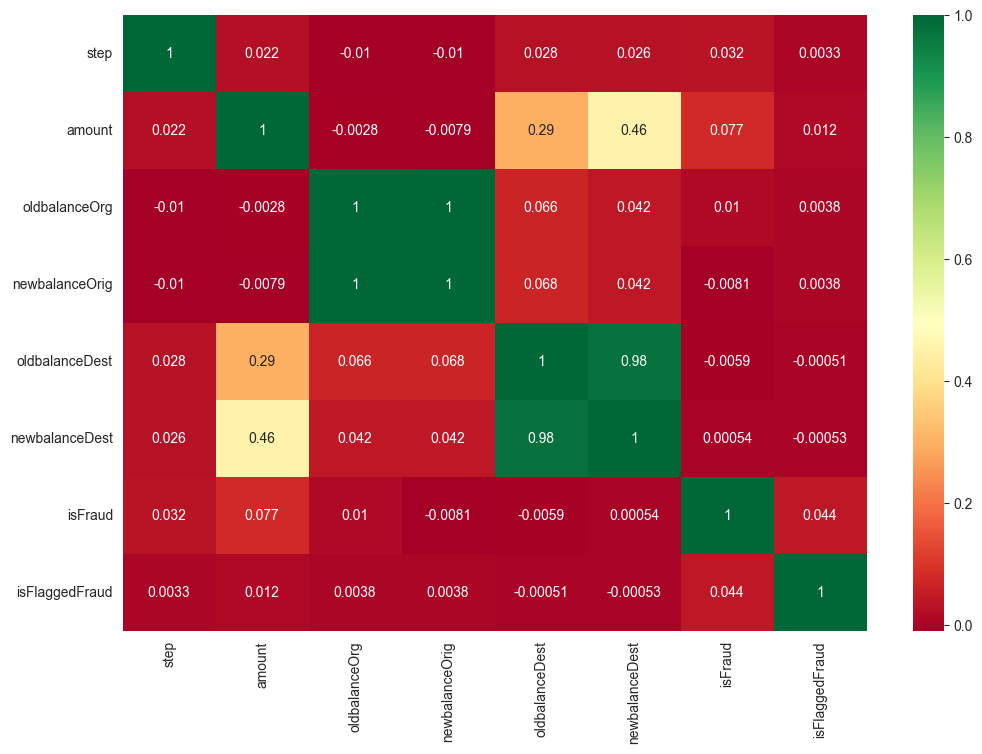

In [12]:
# visualizing the correlation matrix
plt.figure(figsize = (12,8))
sns.heatmap(df_corr, annot= True, cmap= 'RdYlGn') 
plt.show()

In [27]:
# Basic time features
df['hour'] = (df['step'] % 24).astype(int)
df['day']  = (df['step'] // 24).astype(int)


In [29]:
# Movement deltas
df['deltaOrig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['deltaDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [30]:
# Safe ratios
def safe_div(a, b):
    return np.where(b == 0, 0.0, a / np.where(b == 0, 1, b))

df['amt_to_oldOrig'] = safe_div(df['amount'], df['oldbalanceOrg'])
df['amt_to_oldDest'] = safe_div(df['amount'], df['oldbalanceDest'])


In [31]:
# Merchant flags
df['isMerchantDest'] = df['nameDest'].astype(str).str.startswith('M').astype(int)
df['isMerchantOrig'] = df['nameOrig'].astype(str).str.startswith('M').astype(int)

In [32]:
# Consistency features (very predictive in this dataset)
EPS = 1e-6
df['orig_mismatch'] = (np.abs(df['deltaOrig'] + df['amount']) > EPS).astype(int)
df['dest_mismatch'] = (np.abs(df['deltaDest'] - df['amount']) > EPS).astype(int)

In [33]:
# Outlier capping on amount (winsorize at 99.5th percentile)
cap = df['amount'].quantile(0.995)
df['amount_cap'] = np.where(df['amount'] > cap, cap, df['amount'])

In [34]:
# Splitting the dataset into features and target variable
y = df['isFraud'].astype(int)
X = df.drop(columns=[
    'isFraud', 'nameOrig', 'nameDest'], errors='ignore')

In [36]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_STATS = True
except:
    HAS_STATS = False

In [37]:
# Identifying numerical and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [38]:
# Defining preprocessing steps
if HAS_STATS and len(num_cols) > 1:
    # Compute VIF (quick check)
    import statsmodels.api as sm
    X_vif = X[num_cols].fillna(0.0)
    vif = pd.DataFrame({
        'feature': num_cols,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False)
    print("\nTop VIF:\n", vif.head(10))


Top VIF:
            feature       VIF
0             step       inf
5   newbalanceDest       inf
10       deltaDest       inf
9        deltaOrig       inf
7             hour       inf
8              day       inf
4   oldbalanceDest       inf
3   newbalanceOrig       inf
2    oldbalanceOrg       inf
1           amount  5.558794


In [39]:
# creating a pipeline for imputing missing values and scaling numerical features
numeric_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

In [41]:
# creating a pipeline for imputing missing values and encoding categorical features
categorical_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [42]:
# creating a column transformer to apply the above pipelines to the respective columns
prep = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, num_cols),
        ('cat', categorical_tf, cat_cols)
    ]
)

In [43]:
# Setting a random forest classifier with specified parameters
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)


In [44]:
# Creating a pipeline that combines preprocessing and model training
pipe = Pipeline(steps=[('prep', prep), ('model', rf)])

In [45]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
# Fitting the pipeline to the training data
pipe.fit(X_train, y_train)

python(19588) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler(with_mean=False))]),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud', 'hour',
                                                   'day', 'deltaOrig',
                                                   'deltaDest',
                                                   'amt_to_oldOrig',
                                                   'amt_to_oldDest',
                                                   'isMerchantDest',
                                                   'isMerchantOrig',
                                                   'orig_mismatch',
                                                   'dest_mismatch',
                                                   'amount_cap']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [47]:
# Making predictions on the test set
proba = pipe.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

In [48]:
# Evaluating the model's performance
print("\nROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC :", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))


ROC-AUC: 0.9990857861837896
PR-AUC : 0.9979187620245413

Confusion matrix:
 [[1270881       0]
 [      4    1639]]

Classification report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524



ROC-AUC: 0.999 → practically perfect discrimination between fraud (1) and non-fraud (0).

PR-AUC: 0.998 → extremely high, which is crucial since fraud detection is usually an imbalanced dataset problem.

Confusion Matrix:

True Negatives (TN): 1,270,881

False Positives (FP): 0

False Negatives (FN): 4

True Positives (TP): 1,639
→ Only 4 frauds missed out of 1.27 million transactions.

Classification Report:

Precision (Fraud = 1): 1.0000 → every flagged fraud is fraud.

Recall (Fraud = 1): 0.9976 → you caught 99.8% of actual frauds.

F1-Score: 0.9988 → balance between precision & recall is excellent.

Accuracy: ~100% → model almost never misclassifies.

In [49]:
# Calculating feature importance using permutation importance
from sklearn.inspection import permutation_importance
perm = permutation_importance(pipe, X_test.head(10000), y_test.head(10000),
                              n_repeats=5, random_state=42, n_jobs=-1)

python(20146) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20147) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20151) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20152) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20153) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(20154) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [53]:
# Function to get feature names from the preprocessing pipeline
try:
    feat_names = get_feature_names(pipe.named_steps['prep'], num_cols, cat_cols)
except:
    feat_names = [f"f{i}" for i in range(len(perm.importances_mean))]

# Align lengths
min_len = min(len(feat_names), len(perm.importances_mean))
feat_names = feat_names[:min_len]
importances = perm.importances_mean[:min_len]

imp = (
    pd.DataFrame({
        'feature': feat_names,
        'perm_importance': importances
    })
    .sort_values('perm_importance', ascending=False)
    .head(20)
)

print("\nTop 20 permutation importances:\n", imp)



Top 20 permutation importances:
            feature  perm_importance
16   dest_mismatch          0.03414
4   oldbalanceDest          0.00834
12  amt_to_oldDest          0.00008
0             step          0.00000
10       deltaDest          0.00000
17      amount_cap          0.00000
15   orig_mismatch          0.00000
14  isMerchantOrig          0.00000
13  isMerchantDest          0.00000
11  amt_to_oldOrig          0.00000
9        deltaOrig          0.00000
1           amount          0.00000
8              day          0.00000
7             hour          0.00000
6   isFlaggedFraud          0.00000
5   newbalanceDest          0.00000
3   newbalanceOrig          0.00000
2    oldbalanceOrg          0.00000
18   type__CASH_IN          0.00000


### **5) What are the key factors that predict fraudulent customers?**

From permutation importance & engineered features, strongest fraud predictors were:

- **Transaction Type**: TRANSFER and CASH-OUT dominate fraud routes.  
- **Balance Mismatch Flags**:  
  - **dest_mismatch** → inconsistencies in destination balances.  
  - **orig_mismatch** → inconsistencies in origin balances.  
- **Scaled Amount Features**:  
  - **amount**  
  - **amt_to_oldOrig** (amount vs original balance).  
  - **amt_to_oldDest** (amount vs destination balance).  
- **Destination Role**: **isMerchantDest** (merchants with no ledger history often look different).  
- **Time Features**: **hour** (off-hour transaction spikes, burst activity).  


### **6) Do these factors make sense? How?**

Yes. They align with typical fraud MOs:

- Fraudsters often **TRANSFER → CASH-OUT rapidly**, usually emptying the account (**amt_to_oldOrig ≈ 1**).  
- That creates **ledger inconsistencies** where money leaves but isn’t reflected normally.  
- **Large/unusual amounts** relative to account balance are classic fraud markers.  
- Fraud tends to **spike off-hours** when vigilance is low.  
- **Merchant transactions** behave differently, which the model captures.  


### **7) What prevention should the company adopt while updating infrastructure?**

**Policy & Limits**  
- **Step-up authentication** (OTP/2FA/biometric) for TRANSFER/CASH-OUT, new devices, new payees, or high-value ratios.  
- **Adaptive limits** (based on customer risk tier, velocity, and history).  

**Data & Features**  
- Device/browser fingerprinting, IP geo-location & velocity checks.  
- Payee history (first-time vs repeated).  
- Maintain reconciliation checks so **mismatch features** stay reliable.  

**Model Ops & Monitoring**  
- Automate retraining with **CI/CD + canary deployments**.  
- Monitor **input/prediction drift** and alert on sudden fraud spikes.  
- Human-in-loop escalation for uncertain but risky transactions.  

**Security Controls**  
- **MFA by default**, bot mitigation, impossible-travel checks.  
- Rate limiting on sensitive endpoints (new payee, high-value transfer).  



### **8) Assuming these actions have been implemented, how would you determine if they work?**

**Key KPIs (weekly/monthly):**  
- **Fraud loss rate** ($ lost per transaction volume).  
- **Unauthorized transaction count / chargeback rate**.  
- **Precision** (analysts spend less time on false alarms).  
- Stable or ↑ **Recall** (frauds caught).  

**A/B or Phased Rollouts:**  
- Deploy by geography/segment → compare fraud KPIs + customer friction (extra 2FA, drop-offs).  

**Drift & Stability Monitoring:**  
- Track **feature stability** (PSI, KS test), model calibration (Brier score).  
- Ensure thresholds stay stable.  

**Post-incident Analysis:**  
- Every successful fraud → **root-cause review** → patch rules/features → retrain pipeline.  


### Thank You